<a href="https://colab.research.google.com/github/zinduaschool/ml-notes/blob/main/25h-notes/Week%204%20-%20Deep%20Learning%20Foundations/Deep_Learning_Practice_Day_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Our goal is to : Develop a MLP for an image classification problem. And compare it to a CNN

In [6]:
## Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import layers for my nns
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D
from keras.layers import Flatten
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.preprocessing import StandardScaler #important to scale your data before training a nn.
from sklearn.linear_model import LinearRegression
from keras.optimizers import SGD, Adam
from keras.callbacks import EarlyStopping
from keras.layers import Dropout

import keras

In [8]:
# Import the datateset to be used and plot an example of an image
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
print(f"""the size of train images{train_images.shape},
the size of the labels{train_labels.shape},
the size of test images{test_images.shape},
the size of test_labels{test_labels.shape}""")
# keras.datasets.fashion_mnist.load_data()

the size of train images(60000, 28, 28),
the size of the labels(60000,),
the size of test images(10000, 28, 28),
the size of test_labels(10000,)


In [9]:
train_labels[1:9] # so the labels are just some 0-9 digits representing labels
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
# we store them here for later reference

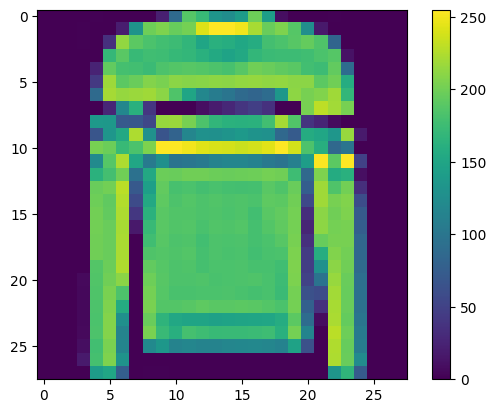

In [10]:
plt.imshow(train_images[5])
plt.colorbar()

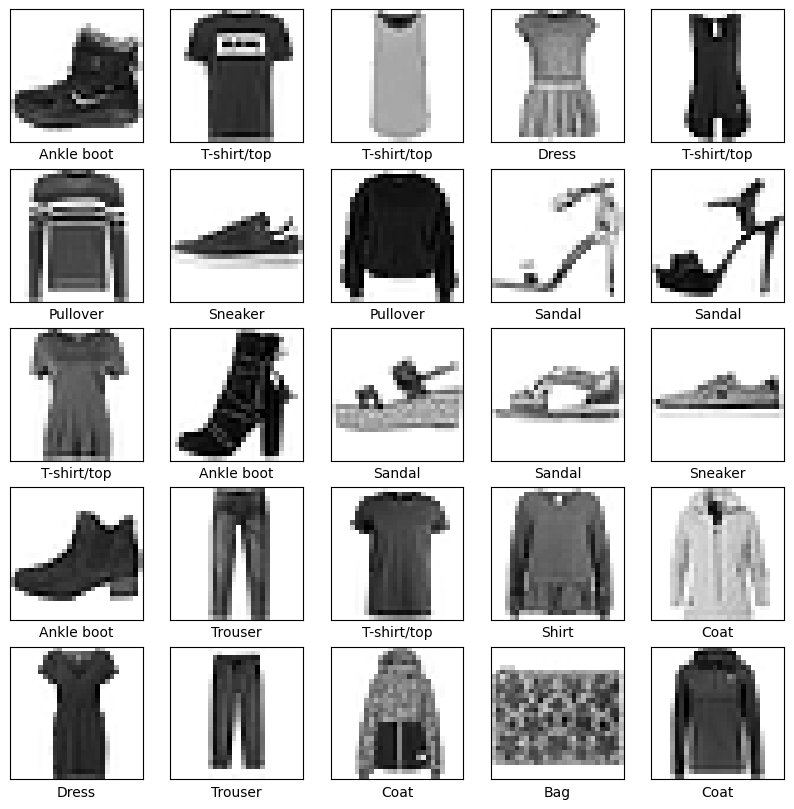

In [12]:
# plot different images in the data and add the labels
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

In [42]:
# Build a multi layer perceptron
model = Sequential([keras.Input(shape=(28, 28)),
                    Flatten(input_shape=(28, 28)), # transforming the images from a 2-d array to a 1 dim array (28*28 = 784
                    Dense(1000, activation='sigmoid'),
                    Dense(500, activation='sigmoid'),
                    Dense(100, activation='relu'),
                    Dense(20, activation='sigmoid'),
                    Dense(10)])

In [43]:
# compile the mlp model
model.compile(optimizer='adam',
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [44]:
# after compiling is to fit the model here it learns to associate the images with labels
stopper=keras.callbacks.EarlyStopping(patience=3) #after 3 non significant improvements we want to stop the model
model.fit(train_images,train_labels,epochs=20,
          validation_split=0.3,# we want to do cross validation of sorts
          callbacks=stopper)
# for these many epochs we need an early stopping

Epoch 1/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 51s 37ms/step - accuracy: 0.5785 - loss: 1.2819 - val_accuracy: 0.6983 - val_loss: 0.7943
Epoch 2/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 77s 33ms/step - accuracy: 0.6780 - loss: 0.8264 - val_accuracy: 0.7003 - val_loss: 0.7902
Epoch 3/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 86s 36ms/step - accuracy: 0.7021 - loss: 0.7692 - val_accuracy: 0.7037 - val_loss: 0.7543
Epoch 4/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 43s 33ms/step - accuracy: 0.7067 - loss: 0.7536 - val_accuracy: 0.7167 - val_loss: 0.7303
Epoch 5/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 44s 33ms/step - accuracy: 0.7122 - loss: 0.7480 - val_accuracy: 0.7093 - val_loss: 0.7236
Epoch 6/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 82s 33ms/step - accuracy: 0.7222 - loss: 0.7005 - val_accuracy: 0.7330 - val_loss: 0.7142
Epoch 7/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 47s 36ms/step - accuracy: 0.7277 - loss: 0.6902 - val_accuracy: 0.6944 - val_loss: 0.7347
Epoch 8/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 45s 34ms/step - accuracy: 0.7298 -

### Now we will define and compile a Convolution Neural Network and See how it performs.

In [1]:
## Simple Conv Net Copied from Keras Example
# Model / data parameters
num_classes = 10
input_shape = (28, 28, 1)

In [4]:
# Load the data and split it between train and test sets
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Scale images to the [0, 1] range
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255
# Make sure images have shape (28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")


# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


In [7]:
# Build the modeld
model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        Conv2D(32, kernel_size=(3, 3), activation="relu"),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, kernel_size=(3, 3), activation="relu"),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dropout(0.5),
        Dense(num_classes, activation="softmax"),
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Train the Model
batch_size = 128
epochs = 15
stopper=keras.callbacks.EarlyStopping(patience=3) #after 3 non significant improvements we want to stop the model
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1,callbacks=stopper)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.7553 - loss: 0.7834 - val_accuracy: 0.9760 - val_loss: 0.0833
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 55ms/step - accuracy: 0.9630 - loss: 0.1217 - val_accuracy: 0.9842 - val_loss: 0.0585
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.9737 - loss: 0.0869 - val_accuracy: 0.9870 - val_loss: 0.0485
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.9778 - loss: 0.0726 - val_accuracy: 0.9885 - val_loss: 0.0407
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 54ms/step - accuracy: 0.9810 - loss: 0.0615 - val_accuracy: 0.9897 - val_loss: 0.0369
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.9831 - loss: 0.0560 - val_accuracy: 0.9912 - val_loss: 0.0332
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.9836 - loss: 0.0516 - val_accuracy: 0.9917 - val_loss: 0.0317
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.9854 - loss: 0.0449 - 

In [9]:
# Test the model on unseen data
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.024270618334412575
Test accuracy: 0.9921000003814697


### How images come and how we sometimes deal with them.

In [14]:
import zipfile

# Download the zip file of the pizza steak images
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

--2025-10-01 18:03:25--  https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.194.207, 173.194.195.207, 209.85.145.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.194.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109540975 (104M) [application/zip]
Saving to: ‘pizza_steak.zip’

pizza_steak.zip     100%[===================>] 104.47M   124MB/s    in 0.8s    

2025-10-01 18:03:26 (124 MB/s) - ‘pizza_steak.zip’ saved [109540975/109540975]



In [16]:
# Unzip the downloaded file
zip_ref = zipfile.ZipFile('pizza_steak.zip', 'r')
zip_ref.extractall()
zip_ref.close()

In [24]:
# !ls pizza_steak/train/
# Count the number of images in the directory
import os
num_of_pizza_images = len(os.listdir('pizza_steak/train/pizza'))
num_of_steak_images = len(os.listdir('pizza_steak/train/steak'))
print(num_of_pizza_images, num_of_steak_images)

750 750


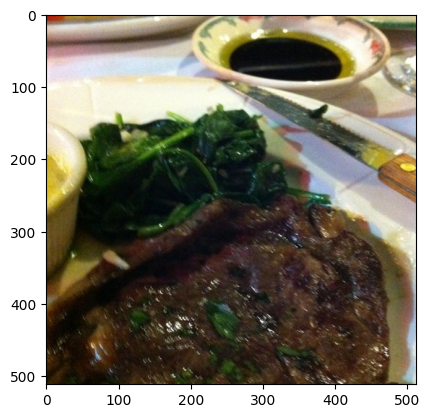

In [34]:
# show me a random image
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# get a random image from the pizza train data
random_image = random.sample(os.listdir('pizza_steak/train/steak'), 1)
# read the image and plot it with plt
img = mpimg.imread(f'pizza_steak/train/steak/{random_image[0]}')
plt.imshow(img)